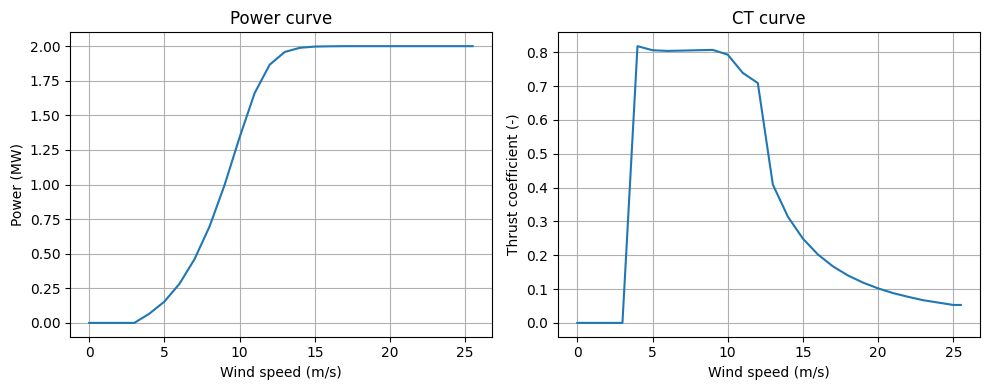

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from py_wake.examples.data.hornsrev1 import V80

wt = V80()

ws = np.arange(0, 26, 0.5)
power = wt.power(ws) / 1e6  # MW
ct = wt.ct(ws)

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# Power curve
axs[0].plot(ws, power)
axs[0].set_xlabel('Wind speed (m/s)')
axs[0].set_ylabel('Power (MW)')
axs[0].set_title('Power curve')
axs[0].grid()

# CT curve
axs[1].plot(ws, ct)
axs[1].set_xlabel('Wind speed (m/s)')
axs[1].set_ylabel('Thrust coefficient (-)')
axs[1].set_title('CT curve')
axs[1].grid()

plt.tight_layout()
plt.savefig("V80_curves.png", dpi=300)
plt.show()

c:\Users\hoeje\OneDrive\Dokumenter\Anaconda\envs\topfarm\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


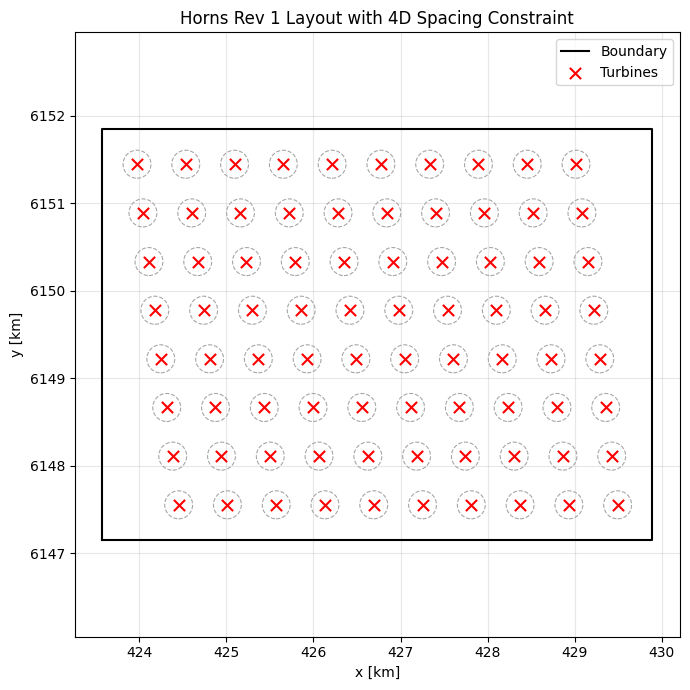

In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from py_wake.examples.data.hornsrev1 import wt_x, wt_y, V80
import numpy as np

wt_x = np.asarray(wt_x)
wt_y = np.asarray(wt_y)

# Convert to km for plotting
wt_x_km = wt_x / 1000
wt_y_km = wt_y / 1000

# Boundary pad
boundary_pad = 400  # [m]
boundary_pad_km = boundary_pad / 1000

xmin = wt_x_km.min() - boundary_pad_km
xmax = wt_x_km.max() + boundary_pad_km
ymin = wt_y_km.min() - boundary_pad_km
ymax = wt_y_km.max() + boundary_pad_km

boundary = np.array([
    [xmin, ymin],
    [xmax, ymin],
    [xmax, ymax],
    [xmin, ymax],
    [xmin, ymin]
])

# 4D spacing
wt = V80()
spacing_D = 4
spacing_radius_km = (spacing_D / 2) * wt.diameter() / 1000

fig, ax = plt.subplots(figsize=(7, 7))

# Boundary
ax.plot(
    boundary[:, 0],
    boundary[:, 1],
    color='black',
    linewidth=1.5,
    label='Boundary',
    zorder=2
)

# 4D spacing circles
for x, y in zip(wt_x_km, wt_y_km):
    circle = Circle(
        (x, y),
        radius=spacing_radius_km,
        edgecolor='black',
        facecolor='none',
        linestyle='--',
        linewidth=0.8,
        alpha=0.35,
        zorder=1
    )
    ax.add_patch(circle)

# Turbines
ax.scatter(
    wt_x_km,
    wt_y_km,
    c='red',
    marker='x',
    s=65,
    label='Turbines',
    zorder=3
)

ax.set_xlabel('x [km]')
ax.set_ylabel('y [km]')
ax.set_title('Horns Rev 1 Layout with 4D Spacing Constraint')
ax.axis('equal')
ax.grid(True, alpha=0.3)
ax.legend(loc='best')
plt.tight_layout()
plt.show()